QUESTION 6 & 7 is done on notebook as they use the same data

In [1]:
# QUESTION 6

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalising the pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

# Building a CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("test acc:", test_acc)


# CNNs are better for image data because they keep the shape of the image and can learn useful visual patterns like edges and textures

# The convolution layer helps the model detect important parts of clothing images

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8016 - loss: 0.5441 - val_accuracy: 0.8647 - val_loss: 0.3622
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8727 - loss: 0.3571 - val_accuracy: 0.8815 - val_loss: 0.3141
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8884 - loss: 0.3070 - val_accuracy: 0.8998 - val_loss: 0.2710
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8980 - loss: 0.2806 - val_accuracy: 0.9013 - val_loss: 0.2637
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9044 - loss: 0.2583 - val_accuracy: 0.9043 - val_loss: 0.2607
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9131 - loss: 0.2402 - val_accuracy: 0.9108 - val_loss: 0.2448
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9175 - loss: 0.2224 - val_accuracy: 0.9105 - val_loss: 0.2463
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9233 - loss: 0.2106 - val_accuracy: 0.

Confusion Matrix:
[[902   1  21   9   5   1  55   0   6   0]
 [  0 987   0   8   2   0   2   0   1   0]
 [ 19   1 907   5  42   0  26   0   0   0]
 [ 31   7  13 901  27   0  20   0   1   0]
 [  1   0  66  16 896   0  21   0   0   0]
 [  0   0   0   0   0 974   0  23   0   3]
 [129   2  85  22  75   0 680   0   7   0]
 [  0   0   0   0   0   3   0 980   0  17]
 [  5   2   1   5   3   2   1   4 977   0]
 [  0   0   1   0   0   4   0  27   0 968]]

Number of misclassified images: 828


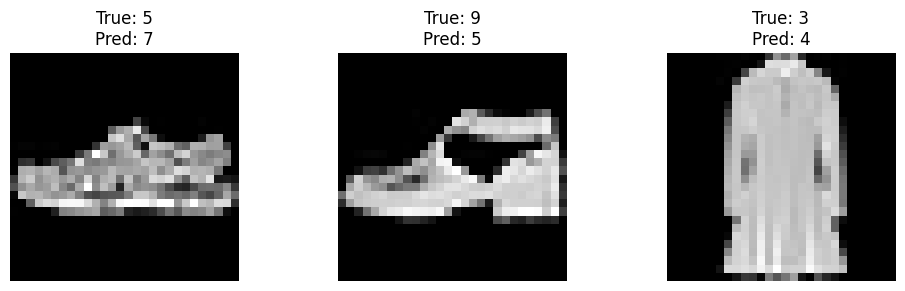

In [4]:
# QUESTION 7

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

test_probs = model.predict(x_test, verbose=0)

y_prediction = np.argmax(test_probs, axis=1)

# Computing the confusion matrix
cm = confusion_matrix(y_test, y_prediction)

print("Confusion Matrix:")
print(cm)

# Finding misclassified images
misclassified_indices = np.where(y_prediction != y_test)[0]

print("\nNumber of misclassified images:", len(misclassified_indices))

plt.figure(figsize=(10, 3))

for i in range(3):
    idx = misclassified_indices[i]

    plt.subplot(1, 3, i + 1)

    # x_test has shape (28, 28, 1), so we remove the last dimension for display
    plt.imshow(x_test[idx].squeeze(), cmap="gray")

    # Show the true and predicted labels
    plt.title(f"True: {y_test[idx]}\nPred: {y_prediction[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# One pattern in the errors is that the CNN may confuse classes with similar shapes

# CNN performance can be made better by training a slightly deeper CNN model and by using more epochs so the model is better trained.